In [130]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [131]:
# from google.colab import files
# uploaded = files.upload()

In [132]:
df = pd.read_csv("egypt_real_estate_listings.csv")

In [133]:
df.head(5)

,url,price,description,location,type,size,bedrooms,bathrooms,available_from,payment_method,down_payment
0,https://www.propertyfinder.eg/en/plp/buy/chale...,"8,000,000",OWN A CHALET IN EL GOUNA WITH A PRIME LOCATION...,"Swan Lake Gouna, Al Gouna, Hurghada, Red Sea",Chalet,732 sqft / 68 sqm,1+ Maid,1,31 Aug 2025,Cash,"1,200,000 EGP"
1,https://www.propertyfinder.eg/en/plp/buy/villa...,"25,000,000","For sale, a villa with immediate delivery in C...","Karmell, New Zayed City, Sheikh Zayed City, Giza",Villa,"2,368 sqft / 220 sqm",4,4,2 Sep 2025,Cash,"2,100,000 EGP"
2,https://www.propertyfinder.eg/en/plp/buy/chale...,"15,135,000","With a down payment of EGP 1,513,000, a fully ...","Azha North, Ras Al Hekma, North Coast",Chalet,"1,270 sqft / 118 sqm",2,2,19 Aug 2025,Cash,"1,513,000 EGP"
3,https://www.propertyfinder.eg/en/plp/buy/apart...,"12,652,000",Own an apartment in New Cairo with a minimal d...,"Taj City, 5th Settlement Compounds, The 5th Se...",Apartment,"1,787 sqft / 166 sqm",3,2,26 Aug 2025,Installments,"1,260,000 EGP"
4,https://www.propertyfinder.eg/en/plp/buy/villa...,"45,250,000",Project: Granville\nLocation: Fifth Settlement...,"Granville, New Capital City, Cairo",Villa,"4,306 sqft / 400 sqm",7,7,2 Sep 2025,Cash,"2,262,500 EGP"


In [134]:
print(df.shape)

(19924, 11)


In [135]:
df.drop(columns=['down_payment', 'available_from','url','description'], inplace=True)

for i in df.columns:
    missing_count = df[i].isna().sum()

    if missing_count > 0.02 * df.shape[0]:
        print(f"Column '{i}': {missing_count} missing values")
        df.dropna(subset=[i], inplace=True)

Column 'price': 539 missing values


In [136]:
df.isna().sum()

price              0
location           0
type               0
size               0
bedrooms          63
bathrooms         59
payment_method     2
dtype: int64

In [137]:
df.info()

<class 'pandas.DataFrame'>
Index: 19385 entries, 0 to 19923
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   price           19385 non-null  str  
 1   location        19385 non-null  str  
 2   type            19385 non-null  str  
 3   size            19385 non-null  str  
 4   bedrooms        19322 non-null  str  
 5   bathrooms       19326 non-null  str  
 6   payment_method  19383 non-null  str  
dtypes: str(7)
memory usage: 1.2 MB


In [138]:
df.describe()

,price,location,type,size,bedrooms,bathrooms,payment_method
count,19385,19385,19385,19385,19322,19326,19383
unique,4286,1525,17,670,18,16,2
top,"10,000,000","Marassi, Sidi Abdel Rahman, North Coast",Apartment,"1,507 sqft / 140 sqm",3,3,Cash
freq,307,419,8280,426,4905,6425,15521


In [139]:
df.head()

,price,location,type,size,bedrooms,bathrooms,payment_method
0,"8,000,000","Swan Lake Gouna, Al Gouna, Hurghada, Red Sea",Chalet,732 sqft / 68 sqm,1+ Maid,1,Cash
1,"25,000,000","Karmell, New Zayed City, Sheikh Zayed City, Giza",Villa,"2,368 sqft / 220 sqm",4,4,Cash
2,"15,135,000","Azha North, Ras Al Hekma, North Coast",Chalet,"1,270 sqft / 118 sqm",2,2,Cash
3,"12,652,000","Taj City, 5th Settlement Compounds, The 5th Se...",Apartment,"1,787 sqft / 166 sqm",3,2,Installments
4,"45,250,000","Granville, New Capital City, Cairo",Villa,"4,306 sqft / 400 sqm",7,7,Cash


In [140]:
X =set()
for i in df['type']:
  X.add(i)
print(X)

{'Chalet', 'Palace', 'Bulk Sale Unit', 'Land', 'Penthouse', 'Cabin', 'Full Floor', 'iVilla', 'Roof', 'Apartment', 'Villa', 'Bungalow', 'Whole Building', 'Twin House', 'Townhouse', 'Hotel Apartment', 'Duplex'}


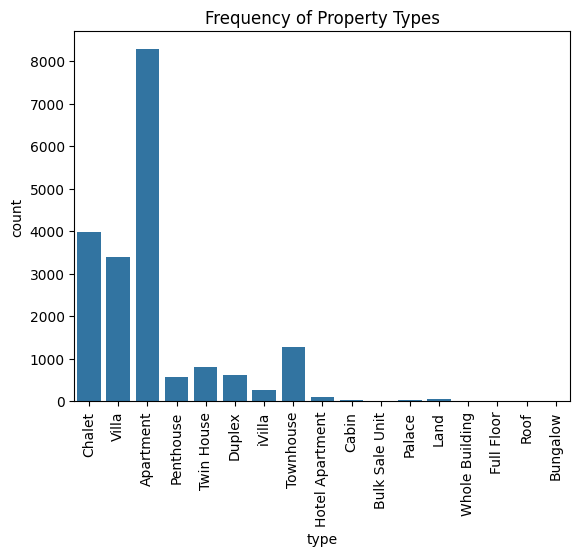

In [141]:
# frequency of each type of property
sns.countplot(data=df, x='type')
plt.title('Frequency of Property Types')
plt.xticks(rotation=90)
plt.show()

In [142]:
# Remove commas from the 'price' column and convert to numeric, coercing errors to NaN
df['price_numeric'] = pd.to_numeric(df['price'].astype(str).str.replace(',', ''), errors='coerce')

df['Price_Millions'] = df['price_numeric'] / 1000000

In [143]:
df.isnull().sum()

price              0
location           0
type               0
size               0
bedrooms          63
bathrooms         59
payment_method     2
price_numeric      0
Price_Millions     0
dtype: int64

In [144]:
#Basic statistics
print("Basic Statistics by Property Type:")
stats = df.groupby('type')['Price_Millions'].describe()
print(stats)

print("\n" + "="*50)
print("COUNT BY PROPERTY TYPE")
print("="*50)
type_counts = df['type'].value_counts()
print(type_counts)

Basic Statistics by Property Type:
                  count        mean        std        min        25%      50%  \
type                                                                            
Apartment        8280.0    8.123080   5.643683   0.186900   4.500000    6.750   
Bulk Sale Unit      3.0   14.034667  14.915266   4.236000   5.452000    6.668   
Bungalow            1.0    3.600000        NaN   3.600000   3.600000    3.600   
Cabin              37.0   14.677658   7.769447   1.000000  10.820061   13.000   
Chalet           3968.0   11.650340   7.334788   0.607000   6.600000   10.250   
Duplex            612.0   13.731225   7.301266   0.800000   8.500000   12.300   
Full Floor          4.0    8.606250   2.017463   7.500000   7.500000    7.650   
Hotel Apartment   102.0   16.502504  15.301337   1.900000   4.892625   13.294   
Land               59.0   15.415254  45.635922   0.800000   2.225000    2.500   
Palace             23.0  153.208167  88.381795  18.000000  75.000000  199.

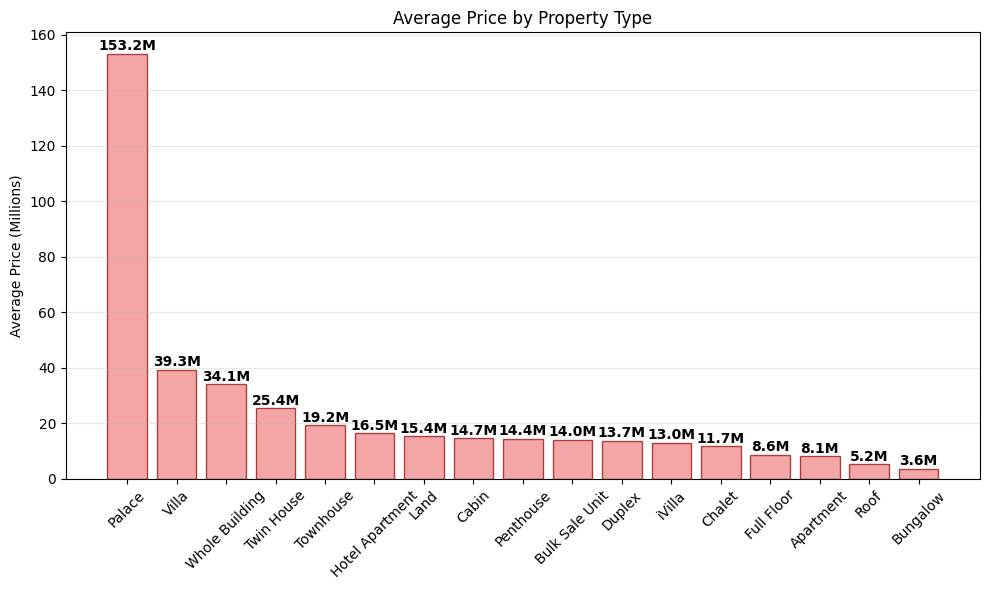

In [145]:
#Average prices bar chart
plt.figure(figsize=(10, 6))
avg_prices = df.groupby('type')['Price_Millions'].mean().sort_values(ascending=False)

bars = plt.bar(avg_prices.index, avg_prices.values, color='lightcoral', alpha=0.7, edgecolor='darkred')
plt.title('Average Price by Property Type')
plt.ylabel('Average Price (Millions)')
plt.xticks(rotation=45)

for bar, value in zip(bars, avg_prices.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{value:.1f}M', ha='center', va='bottom', fontweight='bold')

plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [146]:
rare_types = df['type'].value_counts()[df['type'].value_counts() < 50].index
df = df[~df['type'].isin(rare_types)]

In [147]:
# after cleaning -> remove types
#Basic statistics
print("Basic Statistics by Property Type:")
stats = df.groupby('type')['Price_Millions'].describe()
print(stats)

print("\n" + "="*50)
print("COUNT BY PROPERTY TYPE")
print("="*50)
type_counts = df['type'].value_counts()
print(type_counts)

Basic Statistics by Property Type:
                  count       mean        std       min        25%     50%  \
type                                                                         
Apartment        8280.0   8.123080   5.643683  0.186900   4.500000   6.750   
Chalet           3968.0  11.650340   7.334788  0.607000   6.600000  10.250   
Duplex            612.0  13.731225   7.301266  0.800000   8.500000  12.300   
Hotel Apartment   102.0  16.502504  15.301337  1.900000   4.892625  13.294   
Land               59.0  15.415254  45.635922  0.800000   2.225000   2.500   
Penthouse         560.0  14.376107   8.579658  2.000000   8.528500  12.500   
Townhouse        1270.0  19.207648  10.505781  1.150000  12.162500  18.000   
Twin House        795.0  25.389992  13.937685  0.631082  15.437500  23.000   
Villa            3389.0  39.257629  44.661160  0.631082  16.500000  28.000   
iVilla            262.0  12.970218   5.360765  2.500000   9.258625  12.496   

                       75%  

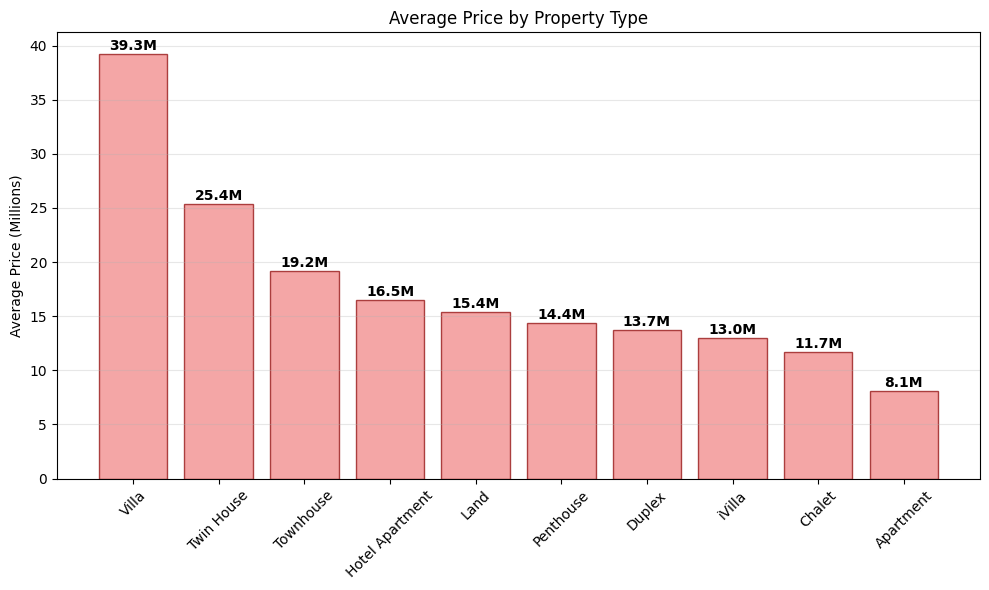

In [148]:
# after cleaning  remove types
#Average prices bar chart
plt.figure(figsize=(10, 6))
avg_prices = df.groupby('type')['Price_Millions'].mean().sort_values(ascending=False)

bars = plt.bar(avg_prices.index, avg_prices.values, color='lightcoral', alpha=0.7, edgecolor='darkred')
plt.title('Average Price by Property Type')
plt.ylabel('Average Price (Millions)')
plt.xticks(rotation=45)

for bar, value in zip(bars, avg_prices.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{value:.1f}M', ha='center', va='bottom', fontweight='bold')

plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [149]:
df['Price_Millions'] = df['Price_Millions'].clip(
    lower=df['Price_Millions'].quantile(0.01),
    upper=df['Price_Millions'].quantile(0.99)
)

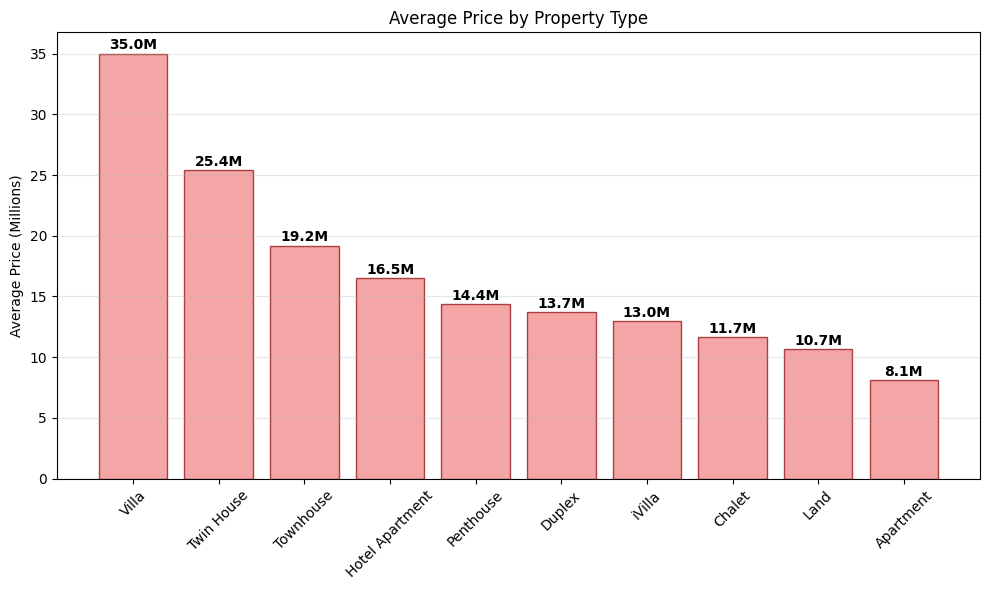

In [150]:
# after cleaning  remove outlires
#Average prices bar chart
plt.figure(figsize=(10, 6))
avg_prices = df.groupby('type')['Price_Millions'].mean().sort_values(ascending=False)

bars = plt.bar(avg_prices.index, avg_prices.values, color='lightcoral', alpha=0.7, edgecolor='darkred')
plt.title('Average Price by Property Type')
plt.ylabel('Average Price (Millions)')
plt.xticks(rotation=45)

for bar, value in zip(bars, avg_prices.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{value:.1f}M', ha='center', va='bottom', fontweight='bold')

plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [151]:
X =set()
for i in df['type']:
  X.add(i)
print(X)

{'Chalet', 'Land', 'Penthouse', 'iVilla', 'Apartment', 'Villa', 'Twin House', 'Townhouse', 'Hotel Apartment', 'Duplex'}


In [152]:
#Detailed analysis by property type
print("="*50)
print("DETAILED ANALYSIS BY PROPERTY TYPE")
print("="*50)

# Convert all unique property types to strings before sorting
for prop_type in sorted(df['type'].unique().astype(str)):
    # Handle the case where the property type is the string 'nan'
    if prop_type == 'nan':
        prop_data = df[df['type'].isna()]['Price_Millions']
    else:
        prop_data = df[df['type'] == prop_type]['Price_Millions']

    print(f"\n{prop_type.upper():<12} ({len(prop_data)} properties):")

    # Check if there is data for the current property type before calculating statistics
    if not prop_data.empty:
        print(f"  Average Price: {prop_data.mean():.2f}M")
        print(f"  Median Price:  {prop_data.median():.2f}M")
        print(f"  Min Price:     {prop_data.min():.2f}M")
        print(f"  Max Price:     {prop_data.max():.2f}M")
        # Ensure min() and max() return scalar values before subtraction
        min_price = prop_data.min()
        max_price = prop_data.max()
        if pd.isna(min_price) or pd.isna(max_price):
          print(f"  Price Range:   N/A")
        else:
          print(f"  Price Range:   {max_price - min_price:.2f}M")
        print(f"  Std Dev:       {prop_data.std():.2f}M")
    else:
        print("  No data available for this property type.")

DETAILED ANALYSIS BY PROPERTY TYPE

APARTMENT    (8280 properties):
  Average Price: 8.13M
  Median Price:  6.75M
  Min Price:     1.37M
  Max Price:     93.50M
  Price Range:   92.13M
  Std Dev:       5.64M

CHALET       (3968 properties):
  Average Price: 11.65M
  Median Price:  10.25M
  Min Price:     1.37M
  Max Price:     74.00M
  Price Range:   72.63M
  Std Dev:       7.33M

DUPLEX       (612 properties):
  Average Price: 13.73M
  Median Price:  12.30M
  Min Price:     1.37M
  Max Price:     52.80M
  Price Range:   51.43M
  Std Dev:       7.30M

HOTEL APARTMENT (102 properties):
  Average Price: 16.50M
  Median Price:  13.29M
  Min Price:     1.90M
  Max Price:     82.00M
  Price Range:   80.10M
  Std Dev:       15.30M

LAND         (59 properties):
  Average Price: 10.68M
  Median Price:  2.50M
  Min Price:     1.37M
  Max Price:     99.04M
  Price Range:   97.67M
  Std Dev:       22.00M

PENTHOUSE    (560 properties):
  Average Price: 14.38M
  Median Price:  12.50M
  Min Price:

In [153]:
import numpy as np

df['Price_log'] = np.log1p(df['Price_Millions'])

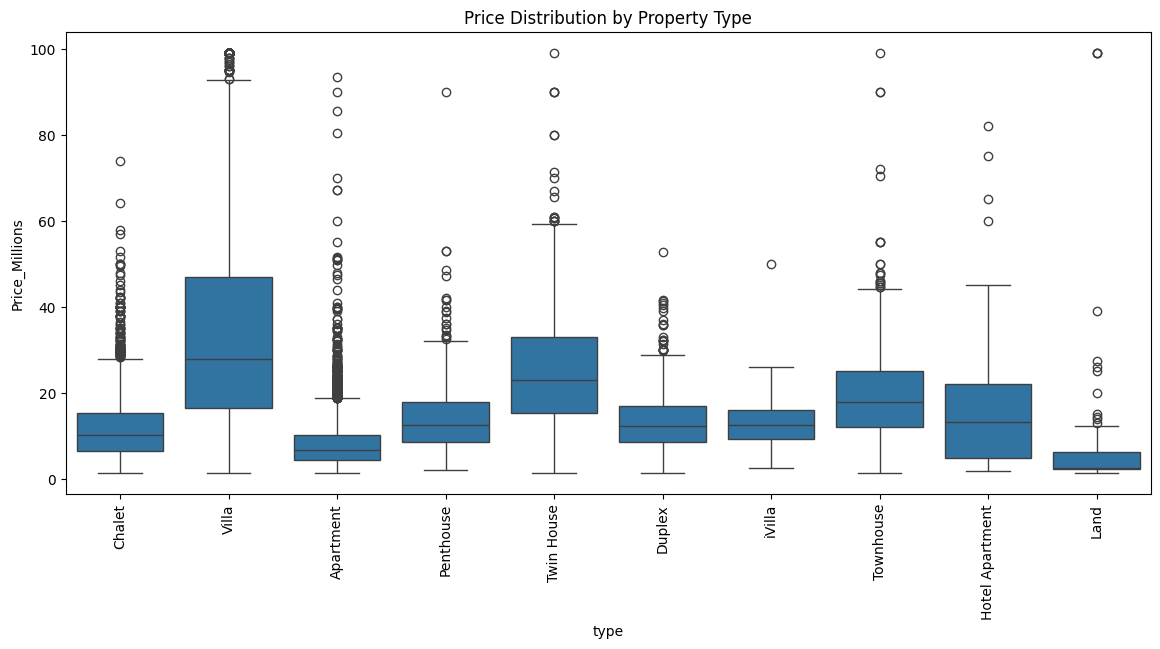

In [154]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
sns.boxplot(data=df, x='type', y='Price_Millions')
plt.xticks(rotation=90)
plt.title('Price Distribution by Property Type')
plt.show()

In [155]:

df.isnull().sum()

price              0
location           0
type               0
size               0
bedrooms          59
bathrooms         59
payment_method     2
price_numeric      0
Price_Millions     0
Price_log          0
dtype: int64

In [156]:
import re

df['Size_sqm'] = (
    df['size']
    .astype(str)
    .str.extract(r'(\d[\d,]*)\s*sqm')[0]
    .str.replace(',', '', regex=False)
    .astype(float)
)

In [157]:
upper_limit = df['Size_sqm'].quantile(0.99)

df = df[df['Size_sqm'] <= upper_limit]

In [158]:
print("\nAVERAGE SIZE BY PROPERTY TYPE:")
avg_sizes = df.groupby('type')['Size_sqm'].mean().round(1)
print(avg_sizes)


AVERAGE SIZE BY PROPERTY TYPE:
type
Apartment          155.6
Chalet             128.3
Duplex             241.4
Hotel Apartment    104.6
Land               573.0
Penthouse          204.0
Townhouse          232.7
Twin House         286.2
Villa              350.9
iVilla             244.6
Name: Size_sqm, dtype: float64


In [159]:
df.isnull().sum()

price              0
location           0
type               0
size               0
bedrooms          50
bathrooms         50
payment_method     2
price_numeric      0
Price_Millions     0
Price_log          0
Size_sqm           0
dtype: int64

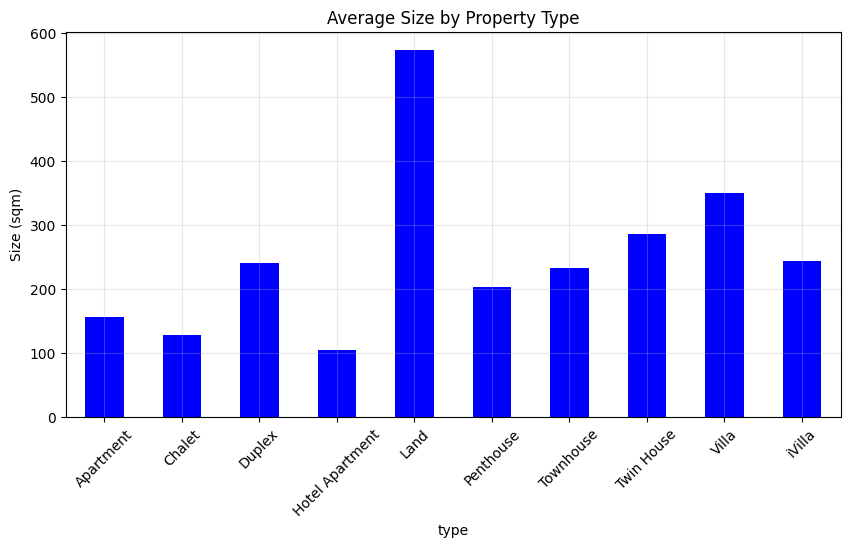

In [160]:
plt.figure(figsize=(10, 5))
avg_sizes.plot(kind='bar', color='blue')
plt.title('Average Size by Property Type')
plt.ylabel('Size (sqm)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

In [161]:
df['Price_per_sqm'] = df['price_numeric'] / df['Size_sqm']

In [162]:
df['Price_per_sqm'].describe()

count    1.910400e+04
mean     7.583571e+04
std      1.504156e+05
min      1.050000e+03
25%      3.913043e+04
50%      6.341463e+04
75%      9.617197e+04
max      1.950000e+07
Name: Price_per_sqm, dtype: float64

In [163]:
upper_limit = df['Price_per_sqm'].quantile(0.99)

df = df[df['Price_per_sqm'] <= upper_limit]

In [164]:
df['Price_per_sqm'].describe()

count     18912.000000
mean      72033.693934
std       44137.869259
min        1050.000000
25%       38888.888889
50%       62919.007491
75%       95000.000000
max      261412.105263
Name: Price_per_sqm, dtype: float64

In [165]:
print("="*40)
print("PROPERTY TYPES COUNT")
print("="*40)

for prop_type, count in df['type'].value_counts().items():
    print(f"{prop_type:<20} : {count}")

PROPERTY TYPES COUNT
Apartment            : 8270
Chalet               : 3935
Villa                : 3090
Townhouse            : 1265
Twin House           : 785
Duplex               : 610
Penthouse            : 558
iVilla               : 262
Hotel Apartment      : 87
Land                 : 50


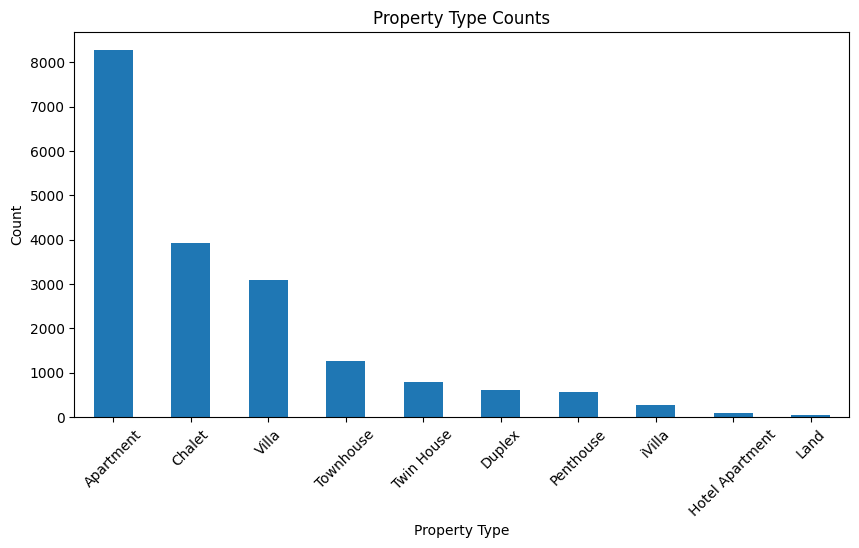

In [166]:
import matplotlib.pyplot as plt

df['type'].value_counts().plot(kind='bar', figsize=(10,5))

plt.title('Property Type Counts')
plt.xlabel('Property Type')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.show()

In [167]:
print(df.shape)

(18912, 12)


In [168]:
df.isnull().sum()

price              0
location           0
type               0
size               0
bedrooms          50
bathrooms         50
payment_method     1
price_numeric      0
Price_Millions     0
Price_log          0
Size_sqm           0
Price_per_sqm      0
dtype: int64

In [169]:
df['bedrooms'] = df['bedrooms'].fillna('').astype(str)

bedroom_numbers = []

for bed in df['bedrooms']:
    bed = str(bed)
    if '+' in bed:
        bed_num = bed.split('+')[0].strip()
    else:
        bed_num = bed.strip()
    
    bedroom_numbers.append(bed_num)

df['Bedroom_Num'] = bedroom_numbers

print("Bedroom Data:")
print(df[['type', 'bedrooms', 'Bedroom_Num']].head())

Bedroom Data:
        type bedrooms Bedroom_Num
0     Chalet  1+ Maid           1
1      Villa        4           4
2     Chalet        2           2
3  Apartment        3           3
4      Villa        7           7


In [170]:
def clean_bedrooms(x):
    x = str(x)

    if 'Studio' in x or 'studio' in x:
        return 1

    if '+' in x:
        base = x.split('+')[0].strip()
        try:
            return int(base)
        except:
            return None

    try:
        return int(x.strip())
    except:
        return None


df['Bedroom_Num'] = df['bedrooms'].apply(clean_bedrooms)

In [171]:
# df['Bedroom_Num'] = pd.to_numeric(df['Bedroom_Num'], errors='coerce')
df['Bedroom_Num'] = df['Bedroom_Num'].fillna(df['Bedroom_Num'].median())
df['Bedroom_Num'] = df['Bedroom_Num'].astype('Int64')

In [172]:
print("Bedroom Data:")
print(df[['type', 'bedrooms', 'Bedroom_Num']].head())

Bedroom Data:
        type bedrooms  Bedroom_Num
0     Chalet  1+ Maid            1
1      Villa        4            4
2     Chalet        2            2
3  Apartment        3            3
4      Villa        7            7


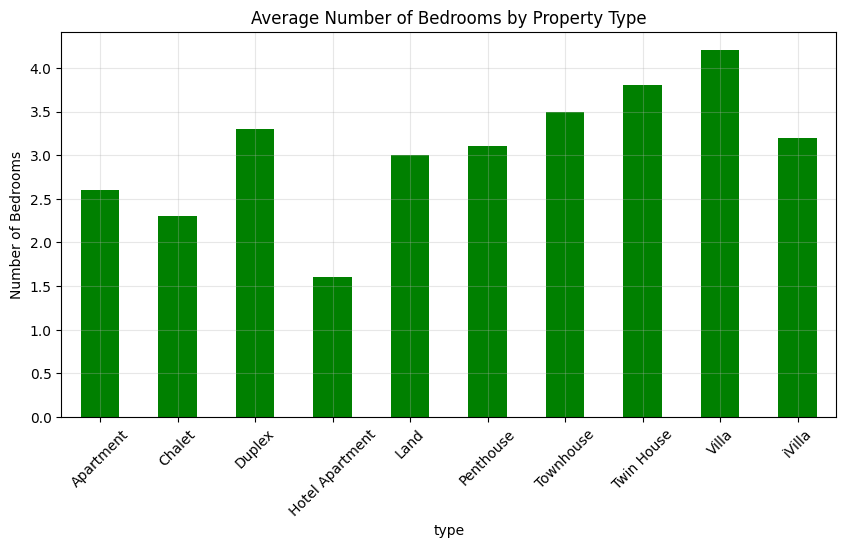

In [173]:
plt.figure(figsize=(10, 5))
avg_bedrooms = df.groupby('type')['Bedroom_Num'].apply(lambda x: pd.to_numeric(x.replace('studio', '1').replace('nan', np.nan), errors='coerce').mean()).round(1)
avg_bedrooms.plot(kind='bar', color='green')
plt.title('Average Number of Bedrooms by Property Type')
plt.ylabel('Number of Bedrooms')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

In [174]:
df.isnull().sum()

price              0
location           0
type               0
size               0
bedrooms           0
bathrooms         50
payment_method     1
price_numeric      0
Price_Millions     0
Price_log          0
Size_sqm           0
Price_per_sqm      0
Bedroom_Num        0
dtype: int64

In [175]:
import pandas as pd
import matplotlib.pyplot as plt
df['bathrooms_numeric'] = pd.to_numeric(df['bathrooms'], errors='coerce')
df['bathrooms_numeric'] = df.groupby('type')['bathrooms_numeric'].transform(
    lambda x: x.fillna(x.median())
)
df['bathrooms_numeric'] = df['bathrooms_numeric'].fillna(df['bathrooms_numeric'].median())
df['bathrooms_numeric'] = df['bathrooms_numeric'].astype(int)

avg_bathroom = df.groupby('type')['bathrooms_numeric'].mean().sort_values()


In [176]:
df['is_land'] = (df['type'] == 'Land').astype(int)
df['has_bedrooms'] = (df['Bedroom_Num'] > 0).astype(int)
df['has_bathrooms'] = (df['bathrooms_numeric'] > 0).astype(int)

print(df[['type', 'bedrooms', 'Bedroom_Num',
          'bathrooms', 'bathrooms_numeric',
          'is_land']].head())

        type bedrooms  Bedroom_Num bathrooms  bathrooms_numeric  is_land
0     Chalet  1+ Maid            1         1                  1        0
1      Villa        4            4         4                  4        0
2     Chalet        2            2         2                  2        0
3  Apartment        3            3         2                  2        0
4      Villa        7            7         7                  7        0


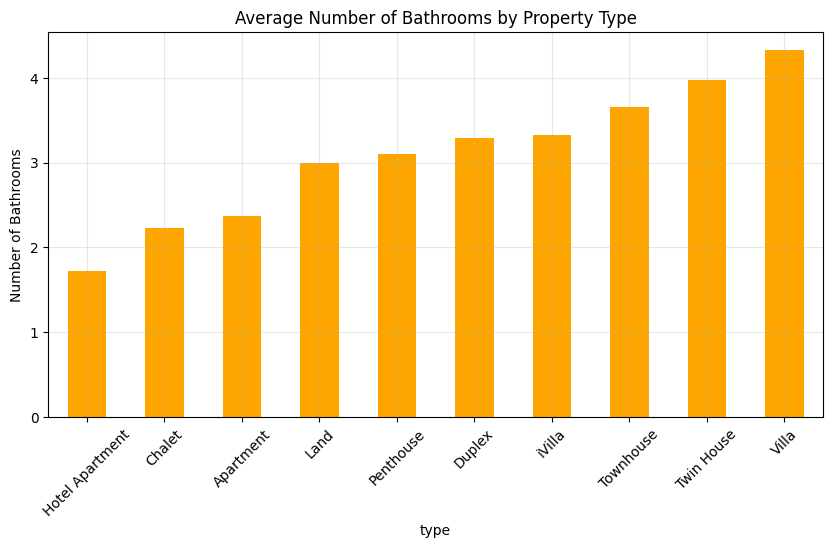

In [177]:
plt.figure(figsize=(10, 5))
avg_bathroom.plot(kind='bar', color='orange')

plt.title('Average Number of Bathrooms by Property Type')
plt.ylabel('Number of Bathrooms')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.show()

In [178]:
df.isnull().sum()

price                 0
location              0
type                  0
size                  0
bedrooms              0
bathrooms            50
payment_method        1
price_numeric         0
Price_Millions        0
Price_log             0
Size_sqm              0
Price_per_sqm         0
Bedroom_Num           0
bathrooms_numeric     0
is_land               0
has_bedrooms          0
has_bathrooms         0
dtype: int64

In [179]:
cross_tab = pd.crosstab(df['type'], df['payment_method'])
print("CROSS-TABULATION:")
print(cross_tab)

CROSS-TABULATION:
payment_method   Cash  Installments
type                               
Apartment        6664          1606
Chalet           2871          1063
Duplex            510           100
Hotel Apartment    50            37
Land               50             0
Penthouse         455           103
Townhouse        1044           221
Twin House        692            93
Villa            2569           521
iVilla            229            33


In [ ]:

df['is_cash'] = df['payment_method'].map({
    'Cash': 1,
    'Installments': 0
})

df['is_cash'] = df['is_cash'].fillna(0).astype(int)

#enhancing installments as a payment method
df['payment_factor'] = df['is_cash'].apply(
    lambda x: 1.0 if x == 1 else 1.10
)

print(df[['payment_method', 'is_cash', 'payment_factor']].head())

  payment_method  is_cash  payment_factor
0           Cash        1            1.00
1           Cash        1            1.00
2           Cash        1            1.00
3   Installments        0            1.15
4           Cash        1            1.00


In [181]:

print(df[['payment_method', 'is_cash']].head())


  payment_method  is_cash
0           Cash        1
1           Cash        1
2           Cash        1
3   Installments        0
4           Cash        1


In [182]:
print(df['is_cash'].value_counts())

is_cash
1    15134
0     3778
Name: count, dtype: int64


In [183]:
df = df.dropna(subset=['is_cash'])

In [184]:
print(df['is_cash'].value_counts(dropna=False))
print("Missing:", df['is_cash'].isnull().sum())

is_cash
1    15134
0     3778
Name: count, dtype: int64
Missing: 0


<Figure size 1000x500 with 0 Axes>

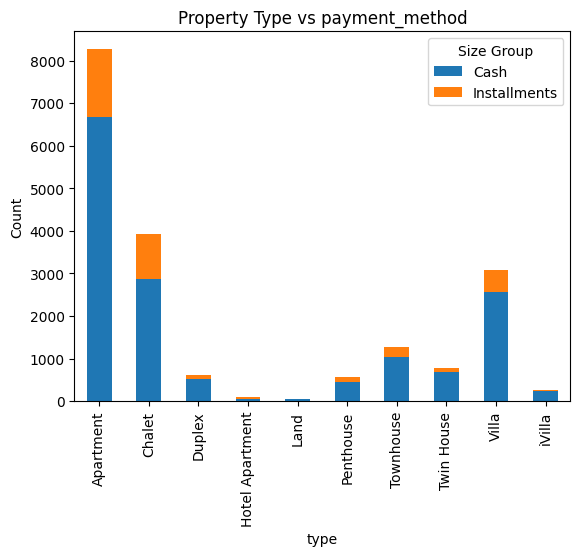

In [185]:

plt.figure(figsize=(10, 5))
cross_tab.plot(kind='bar', stacked=True)
plt.title('Property Type vs payment_method')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.legend(title='Size Group')
plt.show()

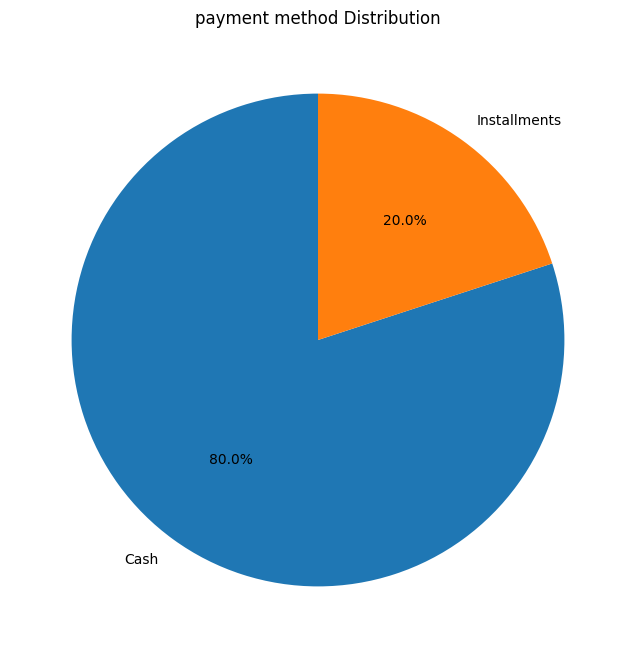

In [186]:

#Pie chart for Payment Methods
plt.figure(figsize=(8, 8))
size_counts = df['payment_method'].value_counts()
plt.pie(size_counts.values, labels=size_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('payment method Distribution')
plt.show()

In [187]:
def preprocess_location(location):

    main_area = str(location).split(',')[-1].strip()
    sub_area = str(location).split(',')[0].strip()

    return main_area, sub_area

In [188]:
import pandas as pd
df['main_area'] = df['location'].apply(lambda x: str(x).split(',')[-1].strip())
df['sub_area'] = df['location'].apply(lambda x: str(x).split(',')[0].strip())

df['main_area'] = df['main_area'].replace({
    'Giza Governorate': 'Giza',
    'Cairo Governorate': 'Cairo'
})

df = pd.get_dummies(df, columns=['main_area'], drop_first=True)

print(df[['location','sub_area']].head())

                                            location         sub_area
0       Swan Lake Gouna, Al Gouna, Hurghada, Red Sea  Swan Lake Gouna
1   Karmell, New Zayed City, Sheikh Zayed City, Giza          Karmell
2              Azha North, Ras Al Hekma, North Coast       Azha North
3  Taj City, 5th Settlement Compounds, The 5th Se...         Taj City
4                 Granville, New Capital City, Cairo        Granville


In [189]:
df['sub_area_freq'] = df['sub_area'].map(df['sub_area'].value_counts())
df['sub_area_freq'] = df['sub_area_freq'].fillna(0)

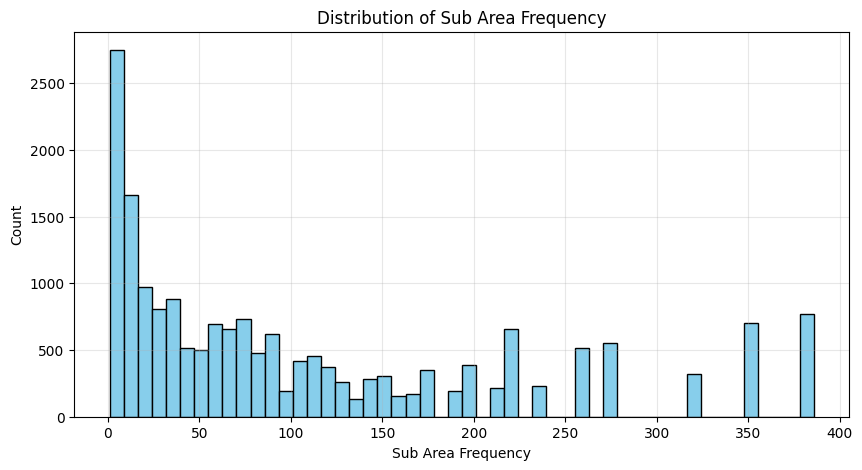

In [190]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(df['sub_area_freq'], bins=50, color='skyblue', edgecolor='black')

plt.title('Distribution of Sub Area Frequency')
plt.xlabel('Sub Area Frequency')
plt.ylabel('Count')
plt.grid(alpha=0.3)

plt.show()

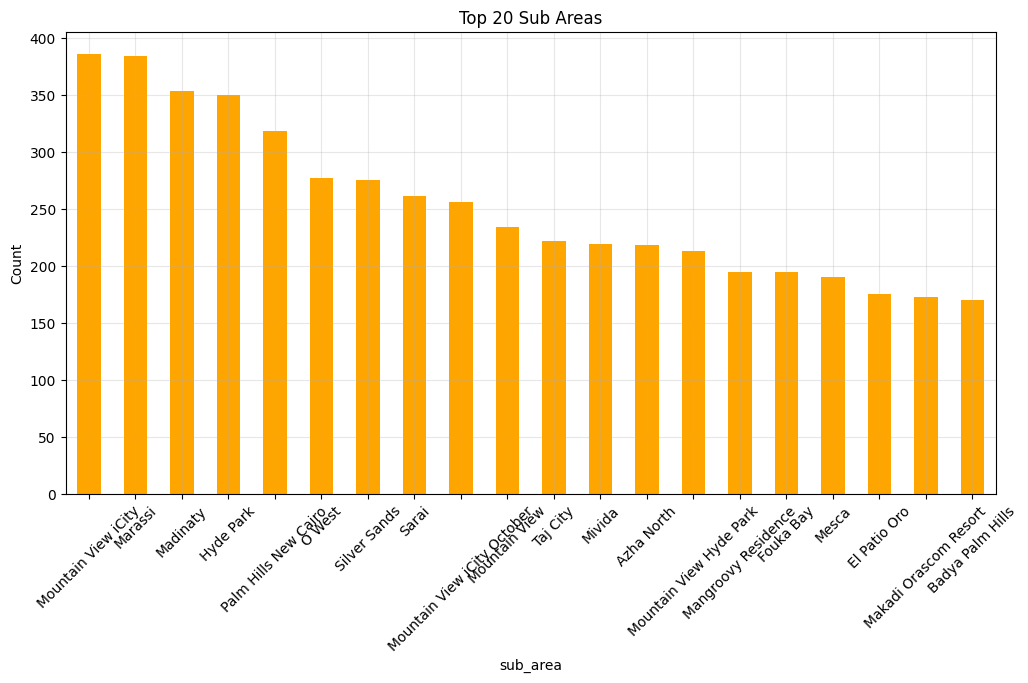

In [191]:
top_sub = df['sub_area'].value_counts().head(20)

plt.figure(figsize=(12,6))
top_sub.plot(kind='bar', color='orange')

plt.title('Top 20 Sub Areas')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.show()

In [192]:
df['Luxury_Property'] = (
    (df['Size_sqm'] > 250) &
    (df['bathrooms_numeric'] >= 3)
).astype(int)

In [193]:
def size_category(size):
    if size < 100:
        return 'Small'
    elif size < 200:
        return 'Medium'
    else:
        return 'Large'

df['Size_Category'] = df['Size_sqm'].apply(size_category)
df = pd.get_dummies(df, columns=['Size_Category'], drop_first=True)



In [194]:
df = pd.get_dummies(df, columns=['type'], drop_first=True)
print([col for col in df.columns if 'type' in col])

['type_Chalet', 'type_Duplex', 'type_Hotel Apartment', 'type_Land', 'type_Penthouse', 'type_Townhouse', 'type_Twin House', 'type_Villa', 'type_iVilla']


In [195]:
from sklearn.model_selection import train_test_split

In [196]:
for col in df.columns:
    print(col)

price
location
size
bedrooms
bathrooms
payment_method
price_numeric
Price_Millions
Price_log
Size_sqm
Price_per_sqm
Bedroom_Num
bathrooms_numeric
is_land
has_bedrooms
has_bathrooms
is_cash
payment_factor
sub_area
main_area_Alexandria
main_area_Aswan
main_area_Asyut
main_area_Cairo
main_area_Demyat
main_area_Giza
main_area_Kafr El Sheikh
main_area_Luxor
main_area_Matrouh
main_area_North Coast
main_area_Qalyubia
main_area_Red Sea
main_area_Sharqia
main_area_South Sainai
main_area_Suez
sub_area_freq
Luxury_Property
Size_Category_Medium
Size_Category_Small
type_Chalet
type_Duplex
type_Hotel Apartment
type_Land
type_Penthouse
type_Townhouse
type_Twin House
type_Villa
type_iVilla


In [197]:
df = df.loc[:, ~df.columns.duplicated()]

In [198]:
for col in df.columns:
    print(col)

price
location
size
bedrooms
bathrooms
payment_method
price_numeric
Price_Millions
Price_log
Size_sqm
Price_per_sqm
Bedroom_Num
bathrooms_numeric
is_land
has_bedrooms
has_bathrooms
is_cash
payment_factor
sub_area
main_area_Alexandria
main_area_Aswan
main_area_Asyut
main_area_Cairo
main_area_Demyat
main_area_Giza
main_area_Kafr El Sheikh
main_area_Luxor
main_area_Matrouh
main_area_North Coast
main_area_Qalyubia
main_area_Red Sea
main_area_Sharqia
main_area_South Sainai
main_area_Suez
sub_area_freq
Luxury_Property
Size_Category_Medium
Size_Category_Small
type_Chalet
type_Duplex
type_Hotel Apartment
type_Land
type_Penthouse
type_Townhouse
type_Twin House
type_Villa
type_iVilla


In [199]:
X = df.drop(columns=[
    'Price_Millions',      # target
    'price',
    'price_numeric',
    'Price_log',
    'location',
    'size',
    'bedrooms',
    'bathrooms',
    'payment_method',
    'sub_area'
])

y = df['Price_Millions']

In [200]:
print(X.shape[1])

37


In [201]:
print(list(X.columns))

['Size_sqm', 'Price_per_sqm', 'Bedroom_Num', 'bathrooms_numeric', 'is_land', 'has_bedrooms', 'has_bathrooms', 'is_cash', 'payment_factor', 'main_area_Alexandria', 'main_area_Aswan', 'main_area_Asyut', 'main_area_Cairo', 'main_area_Demyat', 'main_area_Giza', 'main_area_Kafr El Sheikh', 'main_area_Luxor', 'main_area_Matrouh', 'main_area_North Coast', 'main_area_Qalyubia', 'main_area_Red Sea', 'main_area_Sharqia', 'main_area_South Sainai', 'main_area_Suez', 'sub_area_freq', 'Luxury_Property', 'Size_Category_Medium', 'Size_Category_Small', 'type_Chalet', 'type_Duplex', 'type_Hotel Apartment', 'type_Land', 'type_Penthouse', 'type_Townhouse', 'type_Twin House', 'type_Villa', 'type_iVilla']


In [202]:
X = X.drop(columns=[
    'Price_per_sqm'
])

In [203]:
print(X.shape)
print(y.shape)

print(X.isnull().sum().sum())

(18912, 36)
(18912,)
0


In [204]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [205]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# R2 score
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

print(f"Training R²: {r2_train:.4f}")
print(f"Test R²: {r2_test:.4f}")

# Errors
mae = mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

print(f"MAE: {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")

Training R²: 0.6033
Test R²: 0.5985
MAE: 5.65
RMSE: 8.41


In [206]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

y_pred = ridge.predict(X_test)

print("Ridge R2:", r2_score(y_test, y_pred))

# tuning
alphas = [0.001, 0.01, 0.1, 1, 10, 100]

for a in alphas:
    model = Ridge(alpha=a)
    model.fit(X_train, y_train)
    score = model.score(X_test, y_test)
    print(f"Alpha {a}: R2 = {score:.4f}")

Ridge R2: 0.5987124786806075
Alpha 0.001: R2 = 0.5985
Alpha 0.01: R2 = 0.5985
Alpha 0.1: R2 = 0.5985
Alpha 1: R2 = 0.5987
Alpha 10: R2 = 0.5982
Alpha 100: R2 = 0.5923


In [207]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1, max_iter=10000)
lasso.fit(X_train, y_train)

y_pred = lasso.predict(X_test)

print("Lasso R2:", r2_score(y_test, y_pred))

import pandas as pd

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'coefficient': lasso.coef_
})

selected = feature_importance[feature_importance['coefficient'] != 0]
print("Selected features:", len(selected))

Lasso R2: 0.5751072204479377
Selected features: 11


In [208]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

nn = MLPRegressor(
    hidden_layer_sizes=(100, 50),
    max_iter=10000,
    random_state=42
)

nn.fit(X_train_scaled, y_train)

y_pred = nn.predict(X_test_scaled)

print("NN R2:", r2_score(y_test, y_pred))

NN R2: 0.6710041083787146


In [209]:
import xgboost as xgb

xgb_model = xgb.XGBRegressor(
    objective="reg:squarederror",
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)

print("XGBoost R2:", r2_score(y_test, y_pred))

XGBoost R2: 0.7374089466303324


In [210]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(max_iter=10000),
    "XGBoost": xgb.XGBRegressor(objective="reg:squarederror")
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    results[name] = {
        "R2": r2_score(y_test, pred),
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred))
    }

import pandas as pd
print(pd.DataFrame(results).T)

               R2       MAE      RMSE
Linear   0.598486  5.648077  8.409096
Ridge    0.598712  5.645932  8.406727
Lasso    0.493304  6.453290  9.446540
XGBoost  0.721856  4.224351  6.998969


In [211]:
import joblib

joblib.dump(model, "model.pkl")
joblib.dump(X.columns, "features.pkl")

['features.pkl']

In [212]:
#from google.colab import files
#files.download("model.pkl")
#files.download("features.pkl")

In [213]:
import numpy as np

sample = X_test.iloc[0:1]

pred = model.predict(sample)[0]

print("🏠 Property Features:")
print(sample)

print("\n💰 Predicted Price (Millions):", round(pred, 2))
print("💰 Actual Price (Millions):", y_test.iloc[0])

🏠 Property Features:
       Size_sqm  Bedroom_Num  bathrooms_numeric  is_land  has_bedrooms  \
19915     173.0            3                  3        0             1   

       has_bathrooms  is_cash  payment_factor  main_area_Alexandria  \
19915              1        1             1.0                 False   

       main_area_Aswan  ...  Size_Category_Small  type_Chalet  type_Duplex  \
19915            False  ...                False        False        False   

       type_Hotel Apartment  type_Land  type_Penthouse  type_Townhouse  \
19915                 False      False           False           False   

       type_Twin House  type_Villa  type_iVilla  
19915            False       False        False  

[1 rows x 36 columns]

💰 Predicted Price (Millions): 7.45
💰 Actual Price (Millions): 8.5
